# Generar Espectros

In [2]:
import multirex as mrex
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import pandas as pd
import os
import re
import gc
import warnings
import joblib

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def remove_warnings():
    warnings.filterwarnings("ignore", category=DeprecationWarning)

from sklearn.model_selection import train_test_split

waves=np.loadtxt("waves.txt")
n_points = len(waves)
indices = np.linspace(0, len(waves) - 1, n_points, endpoint=True)
indices = np.round(indices).astype(int)  # Redondear los índices y convertir a entero

# Seleccionar los elementos de la lista usando los índices
puntos_seleccionados = waves[indices]
waves=puntos_seleccionados
wn_grid=np.sort((10000/waves))

Loading MultiREx version 0.3.1


## Load Data

In [3]:
import os
import re
import numpy as np
import pandas as pd

def apply_contaminations_from_files(contamination_files, df, n_points, include_no_contam=False):
    """
    Applies multiple contaminations to the data from a list of contamination files
    and returns a DataFrame with all combinations.

    Parameters:
        contamination_files (list of str): Paths to .txt files containing contaminations.
                                           Expected name pattern: ...fspot<val>_ffac<val>.txt
                                           e.g. epsilon_T3400_fspot0.000_ffac0.000.txt
        df (pandas.DataFrame): Original DataFrame to apply contaminations.
        n_points (int): Number of columns to which the contamination will be applied.
        include_no_contam (bool): If True, also include an explicit non-contaminated
                                  copy (f_spot=0, f_fac=0). If there is also a file
                                  with f_spot=0 and f_fac=0, that file is skipped
                                  to avoid duplicating the same case.

    Returns:
        pandas.DataFrame: DataFrame with all combinations of contaminations, with
        additional columns 'f_spot' and 'f_fac'. Also sets:
            - df_final.data   -> last n_points columns
            - df_final.params -> all other columns
    """
    df_list = []

    # Opción: incluir caso no contaminado "puro" (sin leer de archivo)
    if include_no_contam:
        df_no_contam = df.copy()
        df_no_contam["f_spot"] = 0.0
        df_no_contam["f_fac"] = 0.0
        # Reordenar columnas: primero f_spot, f_fac
        cols = ["f_spot", "f_fac"] + [
            col for col in df_no_contam.columns if col not in ["f_spot", "f_fac"]
        ]
        df_no_contam = df_no_contam[cols]
        df_list.append(df_no_contam)

    # Regex para extraer f_spot y f_fac del nombre:
    # ...fspot<value>_ffac<value>.txt  (el prefijo da igual)
    pattern = r"fspot(?P<f_spot>[0-9.]+)_ffac(?P<f_fac>[0-9.]+)\.txt$"

    for file_path in contamination_files:
        # Verificar que el archivo exista
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"The file {file_path} does not exist.")

        # Extraer f_spot y f_fac del nombre
        filename = os.path.basename(file_path)
        match = re.search(pattern, filename)
        if not match:
            raise ValueError(f"The file name '{filename}' does not match the expected pattern.")

        f_spot = float(match.group("f_spot"))
        f_fac = float(match.group("f_fac"))

        # Si ya incluimos un caso no contaminado "puro", evitamos duplicar el (0,0) del archivo
        if include_no_contam and f_spot == 0.0 and f_fac == 0.0:
            continue

        # Leer datos de contaminación
        try:
            contamination_data = np.loadtxt(file_path, ndmin=2)

            # Columna de epsilon: si hay ≥2 columnas, usamos la segunda
            if contamination_data.shape[1] >= 2:
                contam_values = contamination_data[:, 1]
            else:
                contam_values = contamination_data.flatten()

            # Chequear longitud
            if len(contam_values) != n_points:
                raise ValueError(
                    f"The number of contamination values in '{filename}' ({len(contam_values)}) "
                    f"does not match n_points ({n_points})."
                )
        except Exception as e:
            raise ValueError(f"Error reading the file {file_path}: {e}")

        # (Opcional) invertir orden si tu matriz de datos está al revés en λ
        contam_values = contam_values[::-1]

        # Aplicar contaminación multiplicativa a las últimas n_points columnas
        df_contam = df.copy()
        data_columns = df_contam.columns[-n_points:]
        df_contam[data_columns] = df_contam[data_columns].multiply(contam_values, axis=1)

        # Añadir parámetros de cobertura
        df_contam["f_spot"] = f_spot
        df_contam["f_fac"] = f_fac

        # Reordenar columnas
        cols = ["f_spot", "f_fac"] + [
            col for col in df_contam.columns if col not in ["f_spot", "f_fac"]
        ]
        df_contam = df_contam[cols]

        df_list.append(df_contam)

    # Concatenar todos los casos
    df_final = pd.concat(df_list, ignore_index=True)

    # Atributos convenientes para usar luego
    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]

    return df_final


In [4]:
import joblib
import pandas as pd
import glob

# Cargar el dataset base de K2-18b
k2_18b = joblib.load("specs/k2-18b_data.joblib")

## replace Nan with 0 in  'atm CO2', 'atm CH4','atm H2O', 'atm NH3',
k2_18b[
    ['atm CO2', 'atm CH4','atm H2O', 'atm NH3']
    ] = k2_18b[
        ['atm CO2', 'atm CH4','atm H2O', 'atm NH3']].fillna(0)



In [5]:
# Código corregido para crear espectro plano manteniendo .data y .params
flat = k2_18b[(k2_18b["atm CO2"] == -10) &
              (k2_18b["atm CH4"] == 0) &
              (k2_18b["atm H2O"] == 0) &
              (k2_18b["atm NH3"] == 0)].iloc[0:1].copy()

# Establecer las últimas n_points columnas a 0 (espectro plano)
flat["atm CO2"] = 0
flat.iloc[0, -n_points:] = 0.0023243496509944973

# Mantener tu asignación de .data y .params como la tienes
flat.data = flat.iloc[:, -n_points:]
flat.params = flat.iloc[:, :-n_points]

flat

C:\Users\User\AppData\Local\Temp\ipykernel_76392\760291980.py:12: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  flat.data = flat.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_76392\760291980.py:13: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  flat.params = flat.iloc[:, :-n_points]


,sma,seed,p_radius,p_mass,p_seed,atm temperature,atm base_pressure,atm top_pressure,atm fill_gas,atm cia,...,0.764875,0.756764,0.748855,0.741148,0.733644,0.726317,0.71918,0.712225,0.705435,0.698805
19466,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,"[H2, He]","[H2-H2, H2-He]",...,0.002324,0.002324,0.002324,0.002324,0.002324,0.002324,0.002324,0.002324,0.002324,0.002324


In [6]:
# Todos los archivos de contaminación generados antes:
# TLS/epsilon_T{T}_fspot{...}_ffac{...}.txt
contamination_files = sorted(
    glob.glob("TLS/epsilon_T3500_fspot*_ffac*.txt")
)

print(f"N archivos de contaminación encontrados: {len(contamination_files)}")


N archivos de contaminación encontrados: 16


In [7]:
remove_warnings()  # si ya lo tienes definido en tu código

# 2) Aplicar TODAS las contaminaciones del listado a ese df
try:
    k2_18b_contam = apply_contaminations_from_files(
        contamination_files,
        k2_18b,
        n_points=n_points,  # usa el mismo n_points que en el resto del pipeline
    )
    print("Contaminaciones aplicadas correctamente a k2_18b.")
    print("Shape final:", k2_18b_contam.shape)
    print("Columnas params:", k2_18b_contam.params.columns[:10])
    print("n_points (espectro):", k2_18b_contam.data.shape[1])
except Exception as e:
    print(f"Error processing k2_18b: {e}")


flat_contam = apply_contaminations_from_files(
        contamination_files,
        flat,
        n_points=n_points,  # usa el mismo n_points que en el resto del pipeline
    )


C:\Users\User\AppData\Local\Temp\ipykernel_76392\1714951230.py:92: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
C:\Users\User\AppData\Local\Temp\ipykernel_76392\1714951230.py:93: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_fac"] = f_fac
C:\Users\User\AppData\Local\Temp\ipykernel_76392\1714951230.py:92: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

Contaminaciones aplicadas correctamente a k2_18b.
Shape final: (352800, 409)
Columnas params: Index(['f_spot', 'f_fac', 'sma', 'seed', 'p_radius', 'p_mass', 'p_seed',
       'atm temperature', 'atm base_pressure', 'atm top_pressure'],
      dtype='object')
n_points (espectro): 385


C:\Users\User\AppData\Local\Temp\ipykernel_76392\1714951230.py:92: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
C:\Users\User\AppData\Local\Temp\ipykernel_76392\1714951230.py:93: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_fac"] = f_fac
C:\Users\User\AppData\Local\Temp\ipykernel_76392\1714951230.py:92: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

## Clean data

In [8]:
def mult_df(df, n_points, n_mult):
    """
    Duplicates the DataFrame n_mult+1 times with additional columns 'f_spot' and 'f_fac'
    set to 0.0. The final DataFrame has .data and .params attributes defined based on
    the last n_points columns.
    """
    df_list = []
    for _ in range(n_mult + 1):
        # Non-contaminated case
        df_no_contam = df.copy()
        df_no_contam["f_spot"] = 0.0
        df_no_contam["f_fac"] = 0.0
        # Reorder columns to place 'f_spot' and 'f_fac' at the beginning
        cols = ["f_spot", "f_fac"] + [col for col in df_no_contam.columns if col not in ["f_spot", "f_fac"]]
        df_no_contam = df_no_contam[cols]
        df_list.append(df_no_contam)

    df_final = pd.concat(df_list, ignore_index=True)
    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]

    return df_final

In [9]:
# Número de copias: por ejemplo, igual al número de contaminaciones
n_mult = len(contamination_files) -1
k2_18b_mult = mult_df(k2_18b, n_points=385, n_mult=n_mult)

flat_mult = mult_df(flat, n_points=385, n_mult=n_mult)

print(k2_18b_mult.shape)
print(k2_18b_mult.params.columns[:10])
print(k2_18b_mult.data.shape)


(352800, 409)
Index(['f_spot', 'f_fac', 'sma', 'seed', 'p_radius', 'p_mass', 'p_seed',
       'atm temperature', 'atm base_pressure', 'atm top_pressure'],
      dtype='object')
(352800, 385)


C:\Users\User\AppData\Local\Temp\ipykernel_76392\876726031.py:19: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_76392\876726031.py:20: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, :-n_points]
C:\Users\User\AppData\Local\Temp\ipykernel_76392\876726031.py:19: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_76392\876726031.py:20: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.py

In [10]:
def normalize_min_max_by_row(df):
    min_by_row = df.min(axis=1)
    max_by_row = df.max(axis=1)
    range_by_row = max_by_row - min_by_row
    # Evitar división por cero asignando NaN, que luego reemplazaremos
    normalized = (df.sub(min_by_row, axis=0)).div(range_by_row, axis=0)
    # Manejar filas donde max == min (rango es cero), puedes ajustar este valor
    normalized[range_by_row == 0] = 0  # O cualquier otro valor que consideres apropiado
    return normalized

## Ruido

In [11]:
import numpy as np
import pandas as pd
import warnings


def generate_df_with_noise_std(df, n_repeat, noise_std, seed=None):
    """
    Generates a new DataFrame by applying Gaussian noise with the specified standard
    deviation to the spectra in a vectorized manner and concatenates the result with
    another DataFrame containing additional parameter columns.

    Parameters
    ----------
    df : DataFrame
        Must have 'params' and 'data' attributes (df.params, df.data).
    n_repeat : int
        Number of times each spectrum is replicated.
    noise_std : float or array-like
        - Escalar: mismo sigma para todo.
        - 1D de longitud N_spectra: un sigma por espectro (se copia a todas las λ).
        - 1D de longitud N_wavelengths: un sigma por longitud de onda
          (mismo vector sigma_inst para todas las filas).
    seed : int, optional
        Seed for the random number generator.

    Returns
    -------
    df_final : DataFrame
        With 'params' and 'data' attributes como el original.
    """
    # Check for 'params' and 'data' attributes
    if not hasattr(df, "params"):
        print("Warning: 'params' attribute not found in the DataFrame.")
        df_params = pd.DataFrame()
        if not hasattr(df, "data"):
            print(
                "Warning: 'data' attribute not found in the DataFrame. "
                "Assuming the DataFrame contains only spectra."
            )
            df_spectra = df
    else:
        if not hasattr(df, "data"):
            raise ValueError("The DataFrame must have a 'data' attribute.")
        df_params = df.params
        df_spectra = df.data

    # Basic checks
    if not isinstance(df_spectra, pd.DataFrame):
        raise ValueError("df_spectra must be a pandas DataFrame.")
    if not isinstance(df_params, pd.DataFrame):
        raise ValueError("df_params must be a pandas DataFrame.")
    if not isinstance(n_repeat, int) or n_repeat <= 0:
        raise ValueError("n_repeat must be a positive integer.")
    if seed is not None and (not isinstance(seed, int) or seed < 0):
        raise ValueError("seed must be a non-negative integer.")

    n_spec, n_wl = df_spectra.shape

    # Set seed
    if seed is not None:
        np.random.seed(seed)

    # Replicate spectra
    df_spectra_replicated = pd.DataFrame(
        np.repeat(df_spectra.values, n_repeat, axis=0),
        columns=df_spectra.columns,
    )

    # Expand noise_std
    if isinstance(noise_std, (int, float)):
        if noise_std < 0:
            raise ValueError("noise_std must be non-negative.")
        noise_replicated = np.full(df_spectra_replicated.shape, noise_std)
        noise_std_for_params = np.full(n_spec * n_repeat, noise_std)

    elif isinstance(noise_std, (list, np.ndarray, pd.Series)):
        noise_array = np.asarray(noise_std, dtype=float)
        if np.any(noise_array < 0):
            raise ValueError("All values in noise_std must be non-negative.")
        if noise_array.ndim != 1:
            raise ValueError("noise_std must be 1D if array-like.")

        if len(noise_array) == n_spec:
            # Caso antiguo: un sigma por espectro
            base = noise_array[:, np.newaxis]          # (N_spec, 1)
            base = np.repeat(base, n_repeat, axis=0)   # (N_spec * n_repeat, 1)
            noise_replicated = np.tile(base, (1, n_wl))  # (N_spec * n_repeat, N_wl)
            noise_std_for_params = np.repeat(noise_array, n_repeat)

        elif len(noise_array) == n_wl:
            # NUEVO: un sigma por longitud de onda (CASO sigma_inst PandExo)
            noise_replicated = np.tile(noise_array, (n_spec * n_repeat, 1))
            # En params guardamos, por ejemplo, la media del sigma (opcional)
            noise_std_for_params = np.full(n_spec * n_repeat, noise_array.mean())

        else:
            raise ValueError(
                "If noise_std is array-like, its length must be either "
                "N_spectra or N_wavelengths."
            )
    else:
        raise ValueError(
            "noise_std must be a positive number or a 1D list/array/Series."
        )

    # Apply Gaussian noise
    gaussian_noise = np.random.normal(
        loc=0.0,
        scale=noise_replicated,
        size=df_spectra_replicated.shape,
    )
    df_spectra_replicated = df_spectra_replicated + gaussian_noise

    # Replicate params
    df_params_replicated = pd.DataFrame(
        np.repeat(df_params.values, n_repeat, axis=0),
        columns=df_params.columns,
    )

    # Insert 'noise_std' and 'n_repeat'
    df_params_replicated.insert(0, "noise_std", noise_std_for_params)
    df_params_replicated.insert(1, "n_repeat", n_repeat)

    # Concatenate
    df_final = pd.concat(
        [
            df_params_replicated.reset_index(drop=True),
            df_spectra_replicated.reset_index(drop=True),
        ],
        axis=1,
    )

    # Attach attributes
    warnings.filterwarnings("ignore")
    df_final.data = df_final.iloc[:, -df_spectra_replicated.shape[1] :]
    df_final.params = df_final.iloc[:, : df_params_replicated.shape[1]]
    warnings.filterwarnings("default")

    return df_final


### JWST

In [12]:
import os
import tempfile
import numpy as np
import matplotlib.pyplot as plt
import pandexo.engine.justdoit as jdi

# ==================== Parámetros fijos de K2-18 ====================
MAG_J_K218    = 9.763      # magnitud J
TSTAR_K218    = 3500.0     # K
LOGG_K218     = 4.6        # cgs
MET_K218      = 0.0        # [M/H]
TTRANS_H_K218 = 2.682      # horas

# Profundidad ~ (2.461 R_⊕ / 0.468 R_⊙)^2
DEPTH_K218 = 0.0023243496509944973


def get_k218_prism_noise_flat(
    wl_grid_um,
    depth_rp2_rs2=DEPTH_K218,
    n_transits=10,
    T_s=TSTAR_K218,
    transit_duration_hours=TTRANS_H_K218,
    plot=False,
    cut_first=20,
):
    """
    Devuelve un vector de ruido instrumental representativo para K2-18
    con JWST/NIRSpec Prism, usando un espectro plano (Rp/Rs)^2 sobre
    wl_grid_um. No necesitas un archivo de entrada: la función crea
    uno temporal por dentro y lo borra al final.

    Parameters
    ----------
    wl_grid_um : array-like
        Grid de longitudes de onda en μm.
    depth_rp2_rs2 : float, optional
        Valor constante de (Rp/Rs)^2 para el espectro plano.
        Por defecto ~ (R_p/R_s)^2 para K2-18 b.
    n_transits : int, optional
        Número de tránsitos a simular.
    T_s : float, optional
        Temperatura efectiva de la estrella (K).
    transit_duration_hours : float, optional
        Duración del tránsito en horas.
    plot : bool, optional
        Si True, grafica el espectro simulado con barras de error.
    cut_first : int, optional
        Número de puntos iniciales a recortar del espectro final.

    Returns
    -------
    errors_trim : np.ndarray
        Vector 1D de errores (error_w_floor) recortado.
    """

    wl_grid_um = np.asarray(wl_grid_um, dtype=float)
    depth_arr = np.full_like(wl_grid_um, depth_rp2_rs2, dtype=float)

    # Creamos un archivo temporal PARA PandExo, pero el usuario no lo ve
    tmp_path = None
    try:
        with tempfile.NamedTemporaryFile(mode="w", suffix=".txt", delete=False) as tmp:
            tmp_path = tmp.name
            # formato que espera PandExo: λ(μm), (Rp/Rs)^2
            np.savetxt(tmp, np.column_stack([wl_grid_um, depth_arr]))

        # =============== Configurar PandExo ===============
        exo = jdi.load_exo_dict()

        # Tiempos en segundos
        transit_duration_sec = transit_duration_hours * 3600.0
        baseline_sec = 3.0 * transit_duration_sec

        # Observación
        exo["observation"].update({
            "sat_level": 80,
            "sat_unit": "%",
            "baseline_unit": "total",
            "baseline": baseline_sec,
            "noise_floor": 0,
            "noccultations": n_transits,
        })

        # Estrella K2-18
        exo["star"].update({
            "type": "phoenix",
            "mag": MAG_J_K218,
            "ref_wave": 1.25,   # banda J
            "temp": T_s,
            "metal": MET_K218,
            "logg": LOGG_K218,
        })

        # Planeta: espectro de usuario en el archivo temporal
        exo["planet"].update({
            "type": "user",
            "w_unit": "um",
            "f_unit": "rp^2/r*^2",
            "transit_duration": transit_duration_sec,
            "td_unit": "s",
            "exopath": tmp_path,
        })

        # Instrumento: NIRSpec Prism
        inst = jdi.load_mode_dict("NIRSpec Prism")
        inst["configuration"]["detector"].update({
            "subarray": "sub512",
            "ngroup": 6,
        })

        # Correr PandExo
        results = jdi.run_pandexo(exo, inst)
        waves_full  = results["FinalSpectrum"]["wave"]
        flux_full   = results["FinalSpectrum"]["spectrum"]
        errors_full = results["FinalSpectrum"]["error_w_floor"]

        # Recorte
        if cut_first > 0:
            waves_trim  = waves_full[cut_first:]
            flux_trim   = flux_full[cut_first:]
            errors_trim = errors_full[cut_first:]
        else:
            waves_trim  = waves_full
            flux_trim   = flux_full
            errors_trim = errors_full

        # Plot opcional
        if plot:
            plt.figure(figsize=(8, 4))
            plt.errorbar(
                waves_trim, flux_trim,
                yerr=errors_trim,
                fmt='o', ms=4, elinewidth=1, capsize=2
            )
            plt.xlabel("Wavelength (μm)")
            plt.ylabel("Transit depth (Rp/R*)²")
            plt.title(
                f"PandExo K2-18 — {n_transits} tránsitos, "
                f"T*={T_s:.0f} K, tₜ={transit_duration_hours:.3f} h"
            )
            plt.tight_layout()
            plt.show()

    finally:
        # Borrar el archivo temporal si existe
        if tmp_path is not None and os.path.exists(tmp_path):
            os.remove(tmp_path)

    return waves_trim, errors_trim


# Cargar AE

In [13]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [14]:
autoencoder = keras.models.load_model("AE.keras")

# Eval

In [15]:
import numpy as np

def chi2(x, x_recon, sigma):
    """
    Calcula el estadístico χ² para cada muestra.
    
    Parámetros
    ----------
    x : np.ndarray, shape (n_samples, N)
        Espectros originales.
    x_recon : np.ndarray, shape (n_samples, N)
        Espectros reconstruidos por el autoencoder.
    sigma : np.ndarray, shape (N,)
        Incertidumbres σ_i de cada punto espectral.
    
    Retorna
    -------
    chi2_vals : np.ndarray, shape (n_samples,)
        Valor de χ² para cada muestra.
    """
    return np.sum(((x - x_recon) / sigma)**2, axis=1)


def chi2_r(x, x_recon, sigma, p):
    """
    Calcula el estadístico χ² reducido para cada muestra,
    dado un número de parámetros p manual.
    
    Parámetros
    ----------
    x : np.ndarray, shape (n_samples, N)
        Espectros originales.
    x_recon : np.ndarray, shape (n_samples, N)
        Espectros reconstruidos por el autoencoder.
    sigma : np.ndarray, shape (N,)
        Incertidumbres σ_i de cada punto espectral.
    p : int
        Número de grados de libertad "gastados".
    
    Retorna
    -------
    chi2_red : np.ndarray, shape (n_samples,)
        Valor de χ² reducido para cada muestra.
    """
    chi2_vals = chi2(x, x_recon, sigma)
    N = x.shape[1]
    dof = N - p
    return chi2_vals / dof


def use_model_params(func):
    """
    Decorador que extrae p = nº de parámetros entrenables
    de un modelo Keras y lo pasa a la función chi2_r.
    """
    def wrapper(x, x_recon, sigma, model):
        p = model.count_params()
        return func(x, x_recon, sigma, p)
    return wrapper

@use_model_params
def chi2_r_params(x, x_recon, sigma, p):
    """
    Calcula χ² reducido usando p = nº de parámetros del modelo.
    
    Firma real tras aplicar decorador:
        chi2_r_params(x, x_recon, sigma, model)
    """
    return chi2_r(x, x_recon, sigma, p)


## Incertidumbres

In [16]:
# -*- coding: utf-8 -*-
# === UQ para Autoencoder (AE) — Versión SIMPLIFICADA ===
#
# 1) Incertidumbre ALEATORIA: Fija en 0.5 * Ruido Instrumental.
# 2) Incertidumbre EPISTÉMICA: MC Dropout Directo (Sin batches).
#

from __future__ import annotations

from typing import Optional, Tuple, Dict
import numpy as np
import pandas as pd
import tensorflow as tf

# Umbral para decidir si una fila (espectro) es “plana” (rango ~ 0).
EPS_RANGE = 1e-12

# ---------------------------------------------------------------------------
# 1) INCERTIDUMBRE ALEATORIA (Definición: 0.5 * Instrumental)
# ---------------------------------------------------------------------------
def calc_aleatoric_half_instrumental(
    sigma_inst: np.ndarray | float, 
    shape: Tuple[int, int],
    dtype=np.float32
) -> np.ndarray:
    """
    Calcula la incertidumbre aleatoria como exactamente la mitad del ruido instrumental.
    
    Fórmula: sigma_ale = 0.5 * sigma_inst
    """
    N, D = shape
    FACTOR = 0.5  # Requerimiento fijo
    
    # Aseguramos que sigma_inst sea array del tipo correcto
    if np.ndim(sigma_inst) == 0:
        # Caso: sigma_inst es un escalar único para todo
        s_val = float(sigma_inst)
        sig = np.full((N, D), s_val, dtype=dtype)
    else:
        # Caso: sigma_inst es un vector (D,) o matriz (N, D)
        s_vec = np.asarray(sigma_inst, dtype=dtype)
        
        if s_vec.ndim == 1:
            if s_vec.shape[0] != D:
                 raise ValueError(f"sigma_inst dim {s_vec.shape} no coincide con features D={D}")
            # Broadcasting (D,) -> (N, D)
            sig = np.tile(s_vec, (N, 1))
            
        elif s_vec.ndim == 2:
            if s_vec.shape != (N, D):
                raise ValueError(f"sigma_inst shape {s_vec.shape} no coincide con (N={N}, D={D})")
            sig = s_vec
        else:
            raise ValueError(f"Forma de sigma_inst no soportada: {s_vec.shape}")
            
    return (sig * FACTOR).astype(dtype)


# ---------------------------------------------------------------------------
# 2) INCERTIDUMBRE EPISTÉMICA (MC Dropout) — VERSIÓN BATCH (MEMORIA SEGURA)
# ---------------------------------------------------------------------------
def mc_dropout_sigma_anchor_clean(
    autoencoder,
    x_noisy_raw: pd.DataFrame,
    x_clean_raw: pd.DataFrame,
    t_passes: int = 100,
    batch_size: int = 50_000, 
    dtype=np.float32,
):
    """
    Versión optimizada para memoria. Calcula Mean y Std por lotes (batches).
    Evita OOM (Out of Memory) procesando trozos del dataset y acumulando
    estadísticas localmente.
    """
    # --- 1) Preparar datos (convertir a numpy) ---
    x_noisy = np.asarray(x_noisy_raw.values, dtype=dtype)
    x_clean = np.asarray(x_clean_raw.values, dtype=dtype)
    
    N, D = x_noisy.shape
    
    # Pre-reservar arrays para el resultado final (N, D)
    # Solo guardamos el resultado final, no las 300 pasadas intermedias
    final_mean = np.zeros((N, D), dtype=dtype)
    final_std  = np.zeros((N, D), dtype=dtype)

    print(f"Iniciando MC Dropout por lotes. Total muestras: {N}. Batch size: {batch_size}")

    # --- 2) Iterar por Lotes (Batches) ---
    # En lugar de pasar todo el dataset, vamos trozo a trozo
    num_batches = int(np.ceil(N / batch_size))
    
    for i in range(num_batches):
        start = i * batch_size
        end   = min((i + 1) * batch_size, N)
        
        # Extraer el batch actual
        batch_noisy = x_noisy[start:end]
        batch_clean = x_clean[start:end]
        n_b = batch_noisy.shape[0] # tamaño real de este batch
        
        # --- A) Normalización LOCAL del batch ---
        b_min = batch_noisy.min(axis=1, keepdims=True)
        b_max = batch_noisy.max(axis=1, keepdims=True)
        b_rng = b_max - b_min
        b_rng_safe = np.where(b_rng <= 1e-12, 1.0, b_rng)
        
        batch_norm = (batch_noisy - b_min) / b_rng_safe
        # Si hay filas planas, ponemos ceros
        is_flat = (b_rng[:, 0] <= 1e-12)
        if np.any(is_flat):
            batch_norm[is_flat] = 0.0

        # --- B) Pre-calcular des-normalización (Clean Anchor) ---
        c_min = batch_clean.min(axis=1, keepdims=True)
        c_max = batch_clean.max(axis=1, keepdims=True)
        c_rng = c_max - c_min
        c_is_flat = (c_rng[:, 0] <= 1e-12)

        # --- C) Ejecutar T pasadas SOLO para este batch ---
        # Creamos un acumulador temporal (T, n_b, D) solo para este trocito
        # Esto sí cabe en memoria
        batch_preds = []
        
        for _ in range(t_passes):
            # training=True activa el Dropout
            pred = autoencoder(batch_norm, training=True).numpy().astype(dtype)
            batch_preds.append(pred)
        
        # Convertir a array (T, n_b, D)
        batch_preds = np.stack(batch_preds, axis=0) 
        
        # --- D) Des-normalizar y calcular estadísticas ---
        # Des-normalizar usando clean parameters
        batch_preds_denorm = batch_preds * c_rng[None, :, :] + c_min[None, :, :]
        
        # Corregir planos
        if np.any(c_is_flat):
            # Para los índices planos, rellenar con c_min (constante)
            # Broadcasting cuidadoso necesario, o loop simple:
            # Una forma vectorizada:
            flat_vals = c_min[c_is_flat] # (n_flat, 1)
            # Asignar a todas las pasadas T
            # batch_preds_denorm[:, c_is_flat, :] = flat_vals (broadcast implícito)
            # Para seguridad, iteramos máscara booleana si broadcast falla, pero esto debería servir:
            batch_preds_denorm[:, c_is_flat, :] = flat_vals[:, :]

        # Calcular Media y Std sobre el eje 0 (las pasadas T)
        # Esto colapsa (T, n_b, D) -> (n_b, D)
        m_batch = batch_preds_denorm.mean(axis=0).astype(dtype)
        s_batch = batch_preds_denorm.std(axis=0, ddof=1).astype(dtype)
        
        # --- E) Guardar en el array gigante final ---
        final_mean[start:end] = m_batch
        final_std[start:end]  = s_batch
        
        # Liberar memoria temporal
        del batch_preds, batch_preds_denorm, batch_norm, batch_noisy, batch_clean
        
        # Imprimir progreso cada 10 batches para que sepas que vive
        if i % 10 == 0:
            print(f"   Procesado batch {i+1}/{num_batches}...")

    print("MC Dropout completado.")
    return final_mean, final_std


# ---------------------------------------------------------------------------
# 3) COMBINACIÓN Y UTILIDADES
# ---------------------------------------------------------------------------
def combine_uncertainties(
    sigma_ale: np.ndarray,
    sigma_epi: Optional[np.ndarray] = None,
    sigma_sys: Optional[np.ndarray] = None,
    floor: float = 0.0,
    dtype=np.float32,
) -> np.ndarray:
    """
    Combina incertidumbres en cuadratura.
    sigma_total = sqrt(sigma_ale^2 + sigma_epi^2 + sigma_sys^2)
    """
    sig2 = np.asarray(sigma_ale, dtype=dtype) ** 2
    if sigma_epi is not None:
        sig2 += np.asarray(sigma_epi, dtype=dtype) ** 2
    if sigma_sys is not None:
        sig2 += np.asarray(sigma_sys, dtype=dtype) ** 2
        
    sigma_total = np.sqrt(sig2, dtype=dtype)
    
    if floor > 0.0:
        sigma_total = np.maximum(sigma_total, floor).astype(dtype, copy=False)
        
    return sigma_total


def coverage_metrics(y_true: np.ndarray, y_pred: np.ndarray, sigma: np.ndarray) -> Dict[str, float]:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    sigma = np.asarray(sigma)
    # Evitar división por cero
    sigma = np.where(sigma <= 0.0, np.finfo(sigma.dtype).eps, sigma)
    
    z = (y_true - y_pred) / sigma
    z_abs = np.abs(z)
    return {
        "coverage_1sigma": float(np.mean(z_abs <= 1.0)),
        "coverage_2sigma": float(np.mean(z_abs <= 2.0)),
    }


def sigma_comparison_summary(
    sigma_inst: np.ndarray,   
    sigma_ale: np.ndarray,
    sigma_epi: np.ndarray,
    sigma_total: np.ndarray,
) -> Dict[str, float]:
    N, D = sigma_ale.shape
    # Broadcast de sigma_inst para métricas si es vector
    sigma_inst2 = (
        np.broadcast_to(sigma_inst[None, :], (N, D))
        if sigma_inst.ndim == 1 else sigma_inst
    )

    def _flat(a):
        a = np.asarray(a, dtype=np.float64).ravel()
        return a[np.isfinite(a)]

    def _med_ratio(a, b):
        a1, b1 = _flat(a), _flat(b)
        m = min(a1.size, b1.size)
        if m == 0: return np.nan
        return float(np.median(a1[:m] / np.clip(b1[:m], 1e-12, np.inf)))

    def _corr(a, b):
        a1, b1 = _flat(a), _flat(b)
        m = min(a1.size, b1.size)
        if m < 2: return np.nan
        return float(np.corrcoef(a1[:m], b1[:m])[0, 1])

    return {
        "med_ratio_ale_vs_inst": _med_ratio(sigma_ale, sigma_inst2),
        "med_ratio_epi_vs_inst": _med_ratio(sigma_epi, sigma_inst2),
        "med_ratio_tot_vs_inst": _med_ratio(sigma_total, sigma_inst2),
        "corr_epi_vs_inst": _corr(sigma_epi, sigma_inst2),
    }

## Evaluación en un tránsito

>>> Calculando ruido para T=1 usando grid 'waves' existente...
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation


        Use "format" instead. [pandeia.engine.extinction]


End out of Transit
Starting In Transit Simulation
End In Transit


c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:


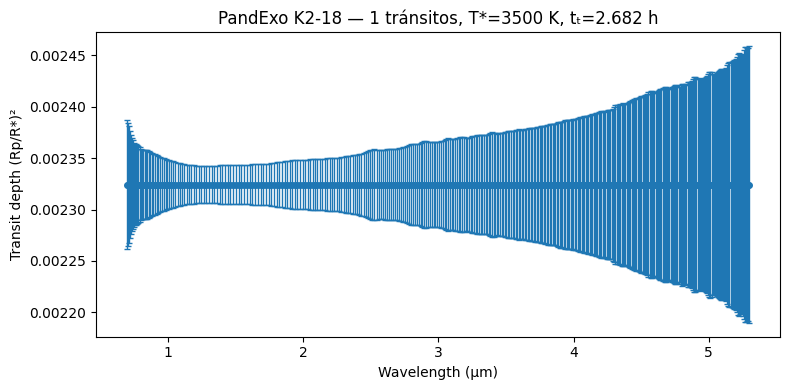

>>> Ruido coincide con n_points: 385
>>> Generando DataFrames...
>>> Ejecutando UQ Pipeline...
Iniciando MC Dropout por lotes. Total muestras: 1063200. Batch size: 50000
   Procesado batch 1/22...
   Procesado batch 11/22...
   Procesado batch 21/22...
MC Dropout completado.
>>> Guardado: dae_uq_outputs_T1.npz

Resultados (T=1):
  - χ²_r medio (Obs-Recon):   21.4449
  - χ²_r medio (Clean-Recon): 0.4570
  - Coverage (Clean) 1σ:      0.890
  - Coverage (Clean) 2σ:      0.981


3572

In [17]:
# === Cell 2 (Corregida: Usando 'waves' global) ===
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import gc

# ---------------- 1. Parámetros de Simulación ----------------
T_TRANSITS = 1             # <--- Ajusta esto (1, 10, etc.)
NREP_PLANET = 3             # Réplicas de planetas
NREP_FLAT   = 300           # Réplicas de planos
T_PASSES_DROPOUT = 50      # Pasadas MC Dropout
EPS_SIGMA = 1e-12           
# n_points y waves se asumen definidos en celdas anteriores

# ---------------- 2. Cálculo de Ruido Instrumental (Dinámico) ----------------
# Usamos 'waves' que ya tienes definido (NO inventamos uno nuevo)
print(f">>> Calculando ruido para T={T_TRANSITS} usando grid 'waves' existente...")

# Nota: get_k218_prism_noise_flat usa pandexo. 
# Si tu variable 'waves' coincide con la resolución del instrumento, 
# la salida debería tener el mismo tamaño (o muy similar tras recortes).

wl_noise_sim =  np.linspace(0.6, 5.3, 1000)
waves_T, sigma_inst = get_k218_prism_noise_flat(
    wl_grid_um=wl_noise_sim,  # <--- USAMOS TU GRID REAL
    n_transits=T_TRANSITS,
    T_s=3500.0,
    plot=True,
    cut_first=18, 
)
sigma_inst = sigma_inst[::-1] # Invertir si es necesario (según tu código previo)
noise = sigma_inst  # alias

# Verificación CRÍTICA de dimensiones
if noise.shape[0] != n_points:
    print(f"¡CUIDADO! Dimensión ruido ({noise.shape[0]}) != n_points ({n_points}).")
    print("Puede que necesites ajustar 'cut_first' en get_k218... o interpolar.")
    # Si la diferencia es pequeña, a veces se recorta o ajusta aquí:
    # noise = noise[:n_points] 
else:
    print(f">>> Ruido coincide con n_points: {noise.shape[0]}")

# ---------------- 3. Construcción de Datasets ----------------
# Generamos los DF ruidosos y limpios al vuelo
print(">>> Generando DataFrames...")

# --- A) Dataset Ruidoso (Input AE) ---
df_noisy = pd.concat([
    generate_df_with_noise_std(k2_18b_contam, NREP_PLANET, noise),
    generate_df_with_noise_std(flat_contam,   NREP_FLAT,   noise)
], ignore_index=True)

# --- B) Dataset Limpio (Target) ---
df_clean = pd.concat([
    generate_df_with_noise_std(k2_18b_mult, NREP_PLANET, 0.0),
    generate_df_with_noise_std(flat_mult,   NREP_FLAT,   0.0)
], ignore_index=True)

# ---------------- 4. Preparación de Señales ----------------
X_noisy_raw = df_noisy.iloc[:, -n_points:]
X_clean_raw = df_clean.iloc[:, -n_points:]

# ---------------- 5. UQ: Aleatoria + Epistémica ----------------
print(">>> Ejecutando UQ Pipeline...")

# (1) Aleatoria (0.5 * Instrumental)
sigma_ale = calc_aleatoric_half_instrumental(noise, X_noisy_raw.shape)

# (2) Epistémica (MC Dropout)
mean_dropout, sigma_epi = mc_dropout_sigma_anchor_clean(
    autoencoder=autoencoder,
    x_noisy_raw=X_noisy_raw,
    x_clean_raw=X_clean_raw,
    t_passes=T_PASSES_DROPOUT
)

# (3) Combinación
sigma_total = combine_uncertainties(sigma_ale, sigma_epi, floor=EPS_SIGMA)
recon_mean  = mean_dropout

# ---------------- 6. Resultados y Métricas ----------------
# Guardar
outfile = f"dae_uq_outputs_T{T_TRANSITS}.npz"
np.savez(outfile, 
         recon_mean=recon_mean, sigma_ale=sigma_ale, 
         sigma_epi=sigma_epi, sigma_total=sigma_total)
print(f">>> Guardado: {outfile}")

# Métricas
try:
    # Obs vs Recon (sigma inst)
    chi2r_obs = chi2_r(X_noisy_raw.values, recon_mean, noise, p=0)
    # Clean vs Recon (sigma total)
    sigT_clip = np.clip(sigma_total, EPS_SIGMA, np.inf)
    chi2r_clean = chi2_r(X_clean_raw.values, recon_mean, sigT_clip, p=0)

    print(f"\nResultados (T={T_TRANSITS}):")
    print(f"  - χ²_r medio (Obs-Recon):   {np.mean(chi2r_obs):.4f}")
    print(f"  - χ²_r medio (Clean-Recon): {np.mean(chi2r_clean):.4f}")

    # Coverage
    cov_tot = coverage_metrics(X_clean_raw.values, recon_mean, sigT_clip)
    print(f"  - Coverage (Clean) 1σ:      {cov_tot['coverage_1sigma']:.3f}")
    print(f"  - Coverage (Clean) 2σ:      {cov_tot['coverage_2sigma']:.3f}")

except NameError:
    print("Funciones de métricas no encontradas.")

# Limpiar memoria
del df_noisy, df_clean
gc.collect()

### plots

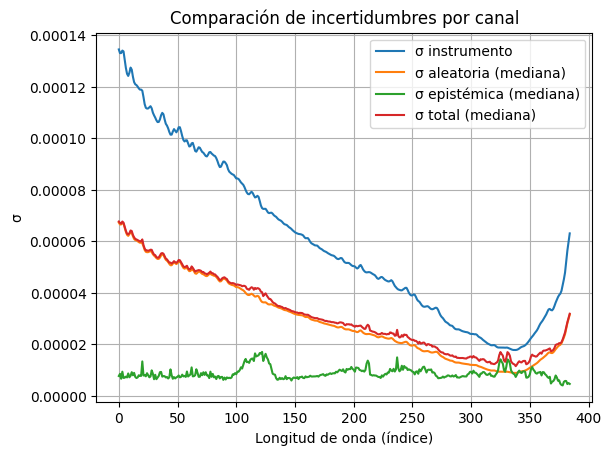

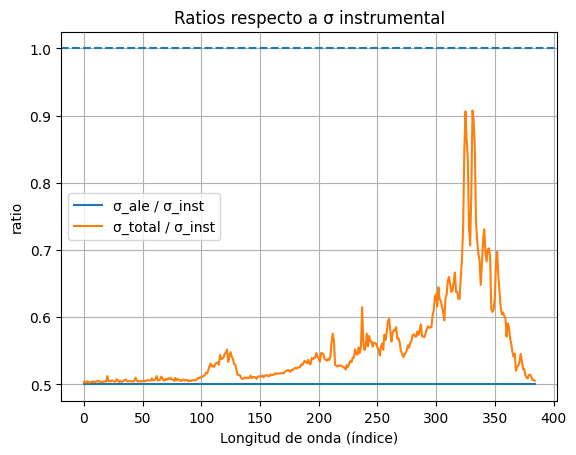


== Coverage (fracción de puntos) ==
Instrumental:  68%=0.953  95%=0.991
Aleatoria:     68%=0.845  95%=0.953
Total (A+E):   68%=0.890  95%=0.981


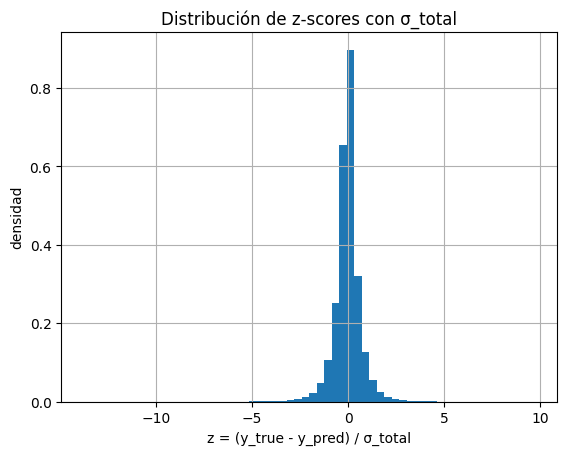


Guardado: C:\Proyectos\Astro\AEspectra\exp 3\sigma_summary.csv


In [18]:
# === Plots & resumen de incertidumbres ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
errors = noiseerrors = noise
def _as_ndarray(x):
    if isinstance(x, (pd.DataFrame, pd.Series)):
        return x.values
    return np.asarray(x)

def _broadcast_sigma_inst(sigma_inst, N, D):
    s = _as_ndarray(sigma_inst)
    if s.ndim == 1:
        if s.shape[0] != D:
            raise ValueError(f"len(sigma_inst)={s.shape[0]} != D={D}")
        sD = s
        sND = np.broadcast_to(s[None, :], (N, D))
    elif s.ndim == 2:
        if s.shape != (N, D):
            raise ValueError(f"sigma_inst shape {s.shape} ≠ (N,D)=({N},{D})")
        sND = s
        sD = s.mean(axis=0)
    else:
        raise ValueError("sigma_inst debe ser (D,) o (N,D)")
    return sD, sND

def _coverage(y_true, y_pred, sigma):
    y_true = _as_ndarray(y_true)
    y_pred = _as_ndarray(y_pred)
    sigma  = _as_ndarray(sigma)
    sigma  = np.where(sigma <= 0, np.finfo(float).eps, sigma)
    z = (y_true - y_pred) / sigma
    z = z[np.isfinite(z)]
    if z.size == 0:
        return np.nan, np.nan, z
    cov1 = float(np.mean(np.abs(z) <= 1.0))
    cov2 = float(np.mean(np.abs(z) <= 2.0))
    return cov1, cov2, z

# ----------- Recolecta variables del entorno -----------
sigma_ale   = _as_ndarray(sigma_ale)         # (N,D)
sigma_epi   = _as_ndarray(sigma_epi)         # (N,D)
sigma_total = _as_ndarray(sigma_total)       # (N,D)
N, D = sigma_ale.shape

sigma_inst_var = errors if 'errors' in globals() else noise   # (D,) o (N,D)
sigma_inst_D, sigma_inst_ND = _broadcast_sigma_inst(sigma_inst_var, N, D)

wl = _as_ndarray(wavelengths) if 'wavelengths' in globals() else np.arange(D)
if wl.shape[0] != D: wl = np.arange(D)

# ----------- Resúmenes por longitud de onda -----------
sigma_ale_med = np.median(sigma_ale, axis=0)
sigma_epi_med = np.median(sigma_epi, axis=0)
sigma_tot_med = np.median(sigma_total, axis=0)
eps = 1e-12
ratio_ale_inst = sigma_ale_med / np.clip(sigma_inst_D, eps, None)
ratio_tot_inst = sigma_tot_med / np.clip(sigma_inst_D, eps, None)

# ----------- Plot 1: σ por canal -----------
plt.figure()
plt.plot(wl, sigma_inst_D, label="σ instrumento")
plt.plot(wl, sigma_ale_med, label="σ aleatoria (mediana)")
plt.plot(wl, sigma_epi_med, label="σ epistémica (mediana)")
plt.plot(wl, sigma_tot_med, label="σ total (mediana)")
plt.xlabel("Longitud de onda" if wl.ndim==1 and wl.dtype!=int else "Longitud de onda (índice)")
plt.ylabel("σ")
plt.title("Comparación de incertidumbres por canal")
plt.legend()
plt.grid(True)
plt.show()

# ----------- Plot 2: Ratios vs instrumento -----------
plt.figure()
plt.plot(wl, ratio_ale_inst, label="σ_ale / σ_inst")
plt.plot(wl, ratio_tot_inst, label="σ_total / σ_inst")
plt.axhline(1.0, linestyle="--")
plt.xlabel("Longitud de onda" if wl.ndim==1 and wl.dtype!=int else "Longitud de onda (índice)")
plt.ylabel("ratio")
plt.title("Ratios respecto a σ instrumentaI")
plt.legend()
plt.grid(True)
plt.show()

# ----------- Coverage + histograma de z (si hay y_true/y_pred) ------
if 'recon_mean' in globals() and 'X_clean_raw' in globals():
    y_pred = _as_ndarray(recon_mean)          # (N,D)
    y_true = _as_ndarray(X_clean_raw)         # (N,D)
    cov1_i, cov2_i, z_i = _coverage(y_true, y_pred, sigma_inst_ND)
    cov1_a, cov2_a, z_a = _coverage(y_true, y_pred, sigma_ale)
    cov1_t, cov2_t, z_t = _coverage(y_true, y_pred, sigma_total)

    print("\n== Coverage (fracción de puntos) ==")
    print(f"Instrumental:  68%={cov1_i:.3f}  95%={cov2_i:.3f}")
    print(f"Aleatoria:     68%={cov1_a:.3f}  95%={cov2_a:.3f}")
    print(f"Total (A+E):   68%={cov1_t:.3f}  95%={cov2_t:.3f}")

    plt.figure()
    plt.hist(z_t, bins=60, density=True)
    plt.xlabel("z = (y_true - y_pred) / σ_total")
    plt.ylabel("densidad")
    plt.title("Distribución de z-scores con σ_total")
    plt.grid(True)
    plt.show()

# ----------- CSV resumen por longitud de onda -----------
summary = pd.DataFrame({
    "lambda": wl if wl.ndim == 1 else np.arange(D),
    "sigma_inst": sigma_inst_D,
    "sigma_ale_med": sigma_ale_med,
    "sigma_epi_med": sigma_epi_med,
    "sigma_total_med": sigma_tot_med,
    "ratio_ale_inst": ratio_ale_inst,
    "ratio_total_inst": ratio_tot_inst,
})
summary_path = Path("sigma_summary.csv")
summary.to_csv(summary_path, index=False)
print(f"\nGuardado: {summary_path.resolve()}")


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["STIXGeneral", "DejaVu Serif", "Times New Roman", "CMU Serif", "Liberation Serif"]
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False

mpl.rcParams["axes.titlesize"]    = 14
mpl.rcParams["axes.titleweight"]  = "normal"
mpl.rcParams["axes.titlepad"]     = 10
mpl.rcParams["figure.titlesize"]  = 16
mpl.rcParams["figure.titleweight"] = "normal"


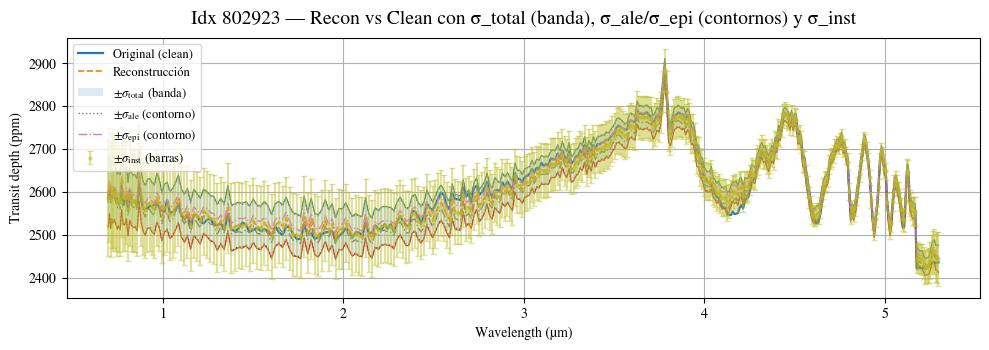

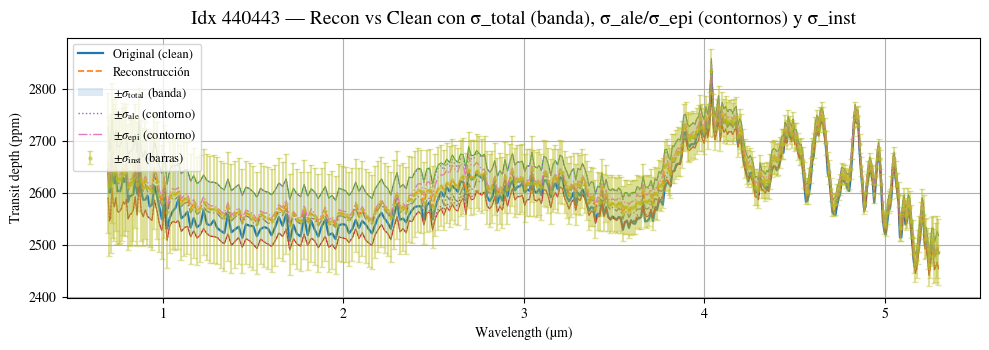

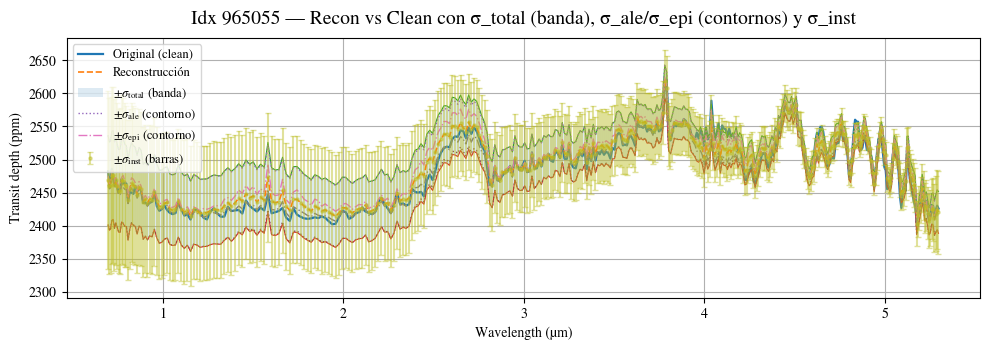

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers ----------
def _as_nd(x):
    import pandas as pd
    if isinstance(x, (pd.DataFrame, pd.Series)): return x.values
    return np.asarray(x)

def _per_sample_sigma(s, i, N, D):
    s = _as_nd(s)
    if s.ndim == 1:
        if s.shape[0] != D: raise ValueError(f"sigma length {s.shape[0]} != D={D}")
        return s
    elif s.ndim == 2:
        if s.shape != (N, D): raise ValueError(f"sigma shape {s.shape} != (N,D)=({N},{D})")
        return s[i]
    raise ValueError("sigma must be (D,) or (N,D)")

# ---------- función principal ----------
def plot_four_sigmas_singlepanel(indices=None, n_random=3, rng_seed=None, ppm=True,
                                 waves_key="wavelengths", show_inst=True,
                                 lw_lines=1.0, lw_edges=0.8, alpha_total=0.15):
    """
    Un panel por espectro:
      - línea clean
      - línea recon
      - banda ±σ_total con borde
      - contornos ±σ_ale y ±σ_epi
      - (opcional) barras ±σ_inst sobre la recon
    """
    # variables requeridas del entorno
    Yc   = _as_nd(X_clean_raw)
    Yr   = _as_nd(recon_mean)
    sig_inst = errors
    sig_ale  = sigma_ale
    sig_epi  = sigma_epi
    sig_tot  = sigma_total

    N, D = Yr.shape

    # eje x
    if waves_key in globals():
        wl = _as_nd(globals()[waves_key])
    elif "waves" in globals():
        wl = _as_nd(globals()["waves"])
    else:
        wl = np.arange(D)
    if wl.shape[0] != D:
        wl = np.arange(D)

    # índices
    rng = np.random.default_rng(rng_seed)
    if indices is None:
        n_random = min(n_random, N)
        idxs = rng.choice(N, size=n_random, replace=False)
    else:
        idxs = np.asarray(indices, dtype=int)

    # escala
    scale = 1e6 if ppm else 1.0
    unit  = "ppm" if ppm else "arb."

    for i in idxs:
        y_clean = Yc[i]
        y_recon = Yr[i]
        s_inst_i = _per_sample_sigma(sig_inst, i, N, D)
        s_ale_i  = _per_sample_sigma(sig_ale,  i, N, D)
        s_epi_i  = _per_sample_sigma(sig_epi,  i, N, D)
        s_tot_i  = _per_sample_sigma(sig_tot,  i, N, D)

        y_clean_p = y_clean * scale
        y_recon_p = y_recon * scale
        s_inst_p  = s_inst_i * scale
        s_ale_p   = s_ale_i  * scale
        s_epi_p   = s_epi_i  * scale
        s_tot_p   = s_tot_i  * scale

        plt.figure(figsize=(10, 3.6))

        # 1) líneas clean & recon
        plt.plot(wl, y_clean_p, lw=1.6, label="Original (clean)")
        plt.plot(wl, y_recon_p, lw=1.2, linestyle="--", label="Reconstrucción")

        # 2) banda ±σ_total con borde
        band = plt.fill_between(wl, y_recon_p - s_tot_p, y_recon_p + s_tot_p,
                                alpha=alpha_total, label=r"±$\sigma_{\rm total}$ (banda)")
        # bordes explícitos de la banda (para que “el shadow tenga borde”)
        plt.plot(wl, y_recon_p + s_tot_p, lw=lw_edges)
        plt.plot(wl, y_recon_p - s_tot_p, lw=lw_edges)

        # 3) contornos ±σ_ale (líneas más finas)
        plt.plot(wl, y_recon_p + s_ale_p, lw=lw_lines, linestyle=":", label=r"±$\sigma_{\rm ale}$ (contorno)")
        plt.plot(wl, y_recon_p - s_ale_p, lw=lw_lines, linestyle=":")

        # 4) contornos ±σ_epi (líneas finas, estilo distinto)
        plt.plot(wl, y_recon_p + s_epi_p, lw=lw_lines, linestyle="-.", label=r"±$\sigma_{\rm epi}$ (contorno)")
        plt.plot(wl, y_recon_p - s_epi_p, lw=lw_lines, linestyle="-.")

        # 5) barras ±σ_inst sobre la recon (referencia de escala)
        if show_inst:
            plt.errorbar(wl, y_recon_p, yerr=s_inst_p, fmt='o', ms=2.2, capsize=2,
                         alpha=0.45, label=r"±$\sigma_{\rm inst}$ (barras)")

        plt.xlabel("Wavelength (µm)" if wl.dtype.kind != 'i' else "Channel index")
        plt.ylabel(f"Transit depth ({unit})")
        plt.title(f"Idx {i} — Recon vs Clean con σ_total (banda), σ_ale/σ_epi (contornos){' y σ_inst' if show_inst else ''}")
        plt.legend(loc="best", fontsize=9, frameon=True)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# ===== Ejemplos =====
# Tres índices aleatorios, mostrando los cuatro sigmas
plot_four_sigmas_singlepanel(n_random=3,  ppm=True)

# Índices fijos
# plot_four_sigmas_singlepanel(indices=[1000, 2000], ppm=True)


0.133 ffac
0.1   fspot

0.3   fspot
0.400 fac

Indices seleccionados (Originales): [5, 337601, 2057]


C:\Users\User\AppData\Local\Temp\ipykernel_76392\1293404920.py:146: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax_mix.set_ylim(y_min_rec - margin_rec, y_max_rec + margin_rec)
C:\Users\User\AppData\Local\Temp\ipykernel_76392\1293404920.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


>>> Plot guardado: plots/exp0-final_style-RANDOM-IndependentAxes-total_uq-1Transit.png


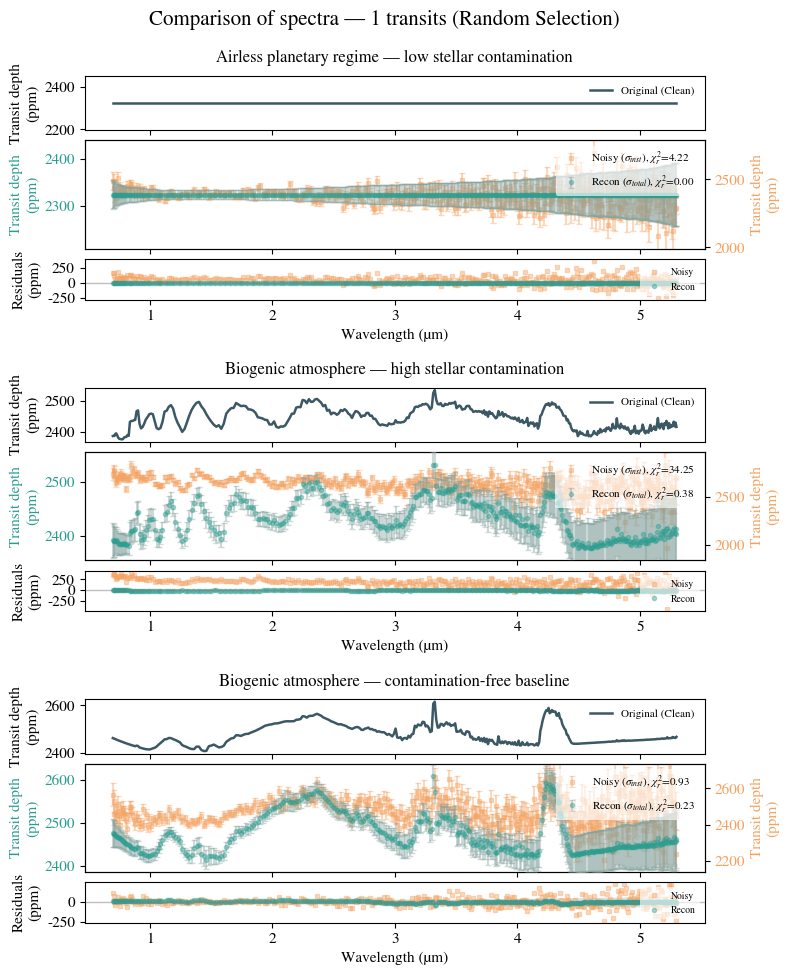

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter
import os 
import random

# --- 1. Carga de Datos y Constantes Globales ---
try:
    y_recon_all = recon_mean
    sigma_total_all = sigma_total
    y_clean_all = X_clean_raw.values
    y_noisy_all = X_noisy_raw.values
    sigma_inst = errors
    waves_i = waves[::-1]
    
    # Constantes necesarias para la navegación de índices
    N_REP_P = NREP_PLANET
    N_REP_F = NREP_FLAT
    LEN_K2_ORIGINAL = len(k2_18b_contam) 
    OFFSET_FLATS = LEN_K2_ORIGINAL * N_REP_P
    
except NameError as e:
    print(f"Error: Variable faltante: {e}")

# --- 2. Función para crear el plot ---
def create_plot_with_your_style(uncertainty_type: str):
    # ==========================================
    # 1. LÓGICA DE SELECCIÓN ALEATORIA
    # ==========================================
    cand_flat = flat_contam[(flat_contam["f_fac"] == 0.133) & (flat_contam["f_spot"] == 0.1)].index
    cand_high = k2_18b_contam[(k2_18b_contam["f_fac"] == 0.400) & (k2_18b_contam["f_spot"] == 0.3)].index
    cand_no   = k2_18b_contam[(k2_18b_contam["f_fac"] == 0.0) & (k2_18b_contam["f_spot"] == 0.0)].index
    
    idx_flat = np.random.choice(cand_flat)
    idx_high = np.random.choice(cand_high)
    idx_no   = np.random.choice(cand_no)
    
    idx_list_orig = [idx_flat, idx_high, idx_no]
    is_flat_mask  = [True, False, False]
    
    print(f"Indices seleccionados (Originales): {idx_list_orig}")

    # ==========================================
    # 2. TU ESTILO
    # ==========================================
    colors = {
        'original':      '#264653',
        'reconstructed': '#2A9D8F',
        'noisy_points':  '#F4A261',
        'fill_uq_resid': '#cccccc80'
    }
    
    custom_titles = [
        "Airless planetary regime — low stellar contamination",
        "Biogenic atmosphere — high stellar contamination",
        "Biogenic atmosphere — contamination-free baseline"
    ]
    plt.rcParams.update({'font.size': 11})

    n_groups = len(idx_list_orig)
    spacer = 2.5
    height_ratios = [val for i in range(n_groups) for val in ([2, 4, 1.5] + ([spacer] if i < n_groups - 1 else []))]

    fig = plt.figure(figsize=(8, 11))
    gs = GridSpec(len(height_ratios), 1, height_ratios=height_ratios, hspace=0.15)

    for i, (idx_orig, is_flat) in enumerate(zip(idx_list_orig, is_flat_mask)):
        
        # --- CÁLCULO DEL ÍNDICE FINAL ---
        if is_flat:
            start_pos = OFFSET_FLATS + (idx_orig * N_REP_F)
            random_offset = np.random.randint(0, N_REP_F)
            final_idx = start_pos + random_offset
        else:
            start_pos = idx_orig * N_REP_P
            random_offset = np.random.randint(0, N_REP_P)
            final_idx = start_pos + random_offset
        # --------------------------------

        base = 4 * i
        ax_orig   = fig.add_subplot(gs[base])
        ax_mix    = fig.add_subplot(gs[base + 1], sharex=ax_orig)
        ax_resid  = fig.add_subplot(gs[base + 2], sharex=ax_orig)

        ax_orig.tick_params(labelbottom=False)
        ax_mix.tick_params(labelbottom=False)

        # --- Datos ---
        y_clean, y_noisy, y_recon = y_clean_all[final_idx], y_noisy_all[final_idx], y_recon_all[final_idx]

        if uncertainty_type == 'instrumental':
            sigma_recon = sigma_inst
            recon_sigma_label = r'\sigma_{inst}'
        else:
            sigma_recon = sigma_total_all[final_idx]
            recon_sigma_label = r'\sigma_{total}'

        # Chi2 
        chi2r_n = chi2_r(y_clean[None, :], y_noisy[None, :], sigma_inst, p=0)[0]
        chi2r_recon = chi2_r(y_clean[None, :], y_recon[None, :], sigma_recon, p=0)[0]

        y_clean_ppm, y_noisy_ppm, y_recon_ppm = y_clean*1e6, y_noisy*1e6, y_recon*1e6
        sigma_inst_ppm, sigma_recon_ppm = sigma_inst*1e6, sigma_recon*1e6

        # --- Panel 1: Original ---
        ax_orig.plot(waves_i, y_clean_ppm, color=colors['original'], lw=1.8, alpha=0.9, label='Original (Clean)')
        ax_orig.set_ylabel("Transit depth\n(ppm)")
        ax_orig.set_title(custom_titles[i], fontsize=12)
        leg1 = ax_orig.legend(fontsize=8, loc='upper right', frameon=True, fancybox=True,
                              facecolor='white', edgecolor='none', framealpha=0.55)
        leg1.set_zorder(1000)
        
        # --- Panel 2: Mix (Twin Axes) ---
        ax_mix_r = ax_mix.twinx()

        formatter = ScalarFormatter(useOffset=False)
        formatter.set_scientific(False)
        ax_orig.yaxis.set_major_formatter(formatter)
        ax_mix.yaxis.set_major_formatter(formatter)
        ax_mix_r.yaxis.set_major_formatter(formatter)

        ax_mix_r.grid(False)
        ax_mix.set_zorder(3); ax_mix_r.set_zorder(2)
        ax_mix.patch.set_alpha(0.0); ax_mix_r.patch.set_alpha(0.0)
        
        ax_mix.set_ylabel("Transit depth\n(ppm)", color=colors['reconstructed'])
        ax_mix.tick_params(axis='y', labelcolor=colors['reconstructed'])
        ax_mix_r.set_ylabel("Transit depth\n(ppm)", color=colors['noisy_points'])
        ax_mix_r.tick_params(axis='y', labelcolor=colors['noisy_points'])
        
        noisy_label = rf"Noisy ($\sigma_{{inst}}$), $\chi^2_r$={chi2r_n:.2f}"
        ax_mix_r.errorbar(waves_i, y_noisy_ppm, yerr=sigma_inst_ppm, color=colors['noisy_points'],
                          fmt='s', capsize=2, alpha=0.4, ms=3, label=noisy_label, zorder=8)
        
        recon_label = rf"Recon (${recon_sigma_label}$), $\chi^2_r$={chi2r_recon:.2f}"
        ax_mix.errorbar(waves_i, y_recon_ppm, yerr=sigma_recon_ppm, color=colors['reconstructed'],
                        fmt='o', capsize=2, alpha=0.4, ms=3, label=recon_label, ecolor='#85A39F', zorder=9)
        
        # --- ESCALAS INDEPENDIENTES (SUELTAS) ---
        # Calculamos los límites individualmente para cada eje con su propio margen
        
        # 1. Ajuste eje Izquierdo (Reconstrucción)
        y_min_rec, y_max_rec = y_recon_ppm.min(), y_recon_ppm.max()
        margin_rec = (y_max_rec - y_min_rec) * 0.15 # Margen del 15%
        ax_mix.set_ylim(y_min_rec - margin_rec, y_max_rec + margin_rec)

        # 2. Ajuste eje Derecho (Ruido)
        y_min_noi, y_max_noi = y_noisy_ppm.min(), y_noisy_ppm.max()
        margin_noi = (y_max_noi - y_min_noi) * 0.15 # Margen del 15%
        ax_mix_r.set_ylim(y_min_noi - margin_noi, y_max_noi + margin_noi)
        # -----------------------------------------

        lines1, labels1 = ax_mix.get_legend_handles_labels()
        lines2, labels2 = ax_mix_r.get_legend_handles_labels()
        leg2 = ax_mix.legend(lines2 + lines1, labels2 + labels1, fontsize=8, loc='upper right',
                             frameon=True, fancybox=True, facecolor='white', edgecolor='none', framealpha=0.65)
        leg2.set_zorder(1000)

        # --- Panel 3: Residuals ---
        resid_n = (y_noisy - y_clean) * 1e6
        resid_r = (y_recon - y_clean) * 1e6
        
        if uncertainty_type == 'instrumental':
            ax_resid.fill_between(waves_i, -sigma_recon_ppm, sigma_recon_ppm,
                                  color=colors['fill_uq_resid'], zorder=5, label=None)
        else:
            ax_resid.fill_between(waves_i, -sigma_recon_ppm, sigma_recon_ppm,
                                  color=colors['fill_uq_resid'], zorder=0,)
        
        ax_resid.plot(waves_i, resid_n, 's', color=colors['noisy_points'], alpha=0.4, ms=3, label='Noisy', zorder=1)
        ax_resid.plot(waves_i, resid_r, 'o', color=colors['reconstructed'], alpha=0.4, ms=3, label='Recon', zorder=2)

        ax_resid.axhline(0, color='gray', lw=1, alpha=0.5)
        ax_resid.set_ylabel("Residuals\n(ppm)")
        ax_resid.set_xlabel("Wavelength (µm)", fontsize=11)
        ax_resid.legend(fontsize=7, loc='upper right', 
         frameon=True, fancybox=True, facecolor='white', edgecolor='none', framealpha=0.65)

    # --- Título y guardado ---
    supt_title = f"Comparison of spectra — {T_TRANSITS} transits (Random Selection)"
    fig.suptitle(supt_title, fontsize=15, y=0.94)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    os.makedirs("plots", exist_ok=True) 
    # Le añadí 'IndependentAxes' al nombre para diferenciarlo
    filename = f"plots/exp0-final_style-RANDOM-IndependentAxes-{uncertainty_type}_uq-{T_TRANSITS}Transit"
    plt.savefig(f"{filename}.png", dpi=300, bbox_inches='tight')
    print(f">>> Plot guardado: {filename}.png")
    
    plt.show()

# --- 3. Ejecutar ---
#create_plot_with_your_style(uncertainty_type='instrumental')
create_plot_with_your_style(uncertainty_type='total')

## Evaluación con muchos tránsitos

In [23]:
# Número de copias: por ejemplo, igual al número de contaminaciones
n_mult = len(contamination_files) -1
k2_18b_mult = mult_df(k2_18b, n_points=385, n_mult=0)

flat_mult = mult_df(flat, n_points=385, n_mult=0)

print(k2_18b_mult.shape)
print(k2_18b_mult.params.columns[:10])
print(k2_18b_mult.data.shape)


(22050, 409)
Index(['f_spot', 'f_fac', 'sma', 'seed', 'p_radius', 'p_mass', 'p_seed',
       'atm temperature', 'atm base_pressure', 'atm top_pressure'],
      dtype='object')
(22050, 385)


C:\Users\User\AppData\Local\Temp\ipykernel_76392\876726031.py:19: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_76392\876726031.py:20: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, :-n_points]
C:\Users\User\AppData\Local\Temp\ipykernel_76392\876726031.py:19: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_76392\876726031.py:20: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.py

In [28]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from tqdm import tqdm
import pickle
import gc

# ===========================================================
# 1. CONFIGURACIÓN Y CONSTANTES
# ===========================================================
N_TRANSITS_LIST = [1, 2, 5, 10]

# Parámetros UQ
NREP_PLANET = 3           
NREP_FLAT   = 300         
T_PASSES_DROPOUT = 50     
EPS_SIGMA = 1e-12 

# Grid
WL_GRID_SIM = np.linspace(0.6, 5.3, 1000)

# Valores únicos
unique_f_spot = np.sort(flat_contam["f_spot"].unique())
unique_f_fac  = np.sort(flat_contam["f_fac"].unique())

print(f">>> Valores f_spot: {unique_f_spot}")
print(f">>> Valores f_fac:  {unique_f_fac}")

# ===========================================================
# 2. FUNCIONES AUXILIARES
# ===========================================================
def filtrar_data(df, f_spot_val, f_fac_val):
    return df[(df["f_spot"] == f_spot_val) & (df["f_fac"] == f_fac_val)]

# ===========================================================
# 3. MAESTRO LIMPIO (Una vez)
# ===========================================================
print("Building master CLEAN dataset (one-time)...")
df_clean_maestro = pd.concat([
    generate_df_with_noise_std(k2_18b_mult, NREP_PLANET, 0.0),
    generate_df_with_noise_std(flat_mult,   NREP_FLAT,   0.0)
], ignore_index=True)

print(f"Master CLEAN dataset ready. ✅ Shape: {df_clean_maestro.shape}")

# ===========================================================
# 4. BUCLE PRINCIPAL
# ===========================================================
all_results = {}

print("\nStarting sensitivity & UQ analysis...")

for f_spot_val in unique_f_spot:
    for f_fac_val in unique_f_fac:
        
        # --- Filtrar el Limpio (Una vez por par estelar) ---
        df_clean_filtered = df_clean_maestro
        
        # Si está vacío, saltamos
        if df_clean_filtered.empty:
            continue
            
        # Extraemos X limpia
        X_clean_raw = df_clean_filtered.iloc[:, -n_points:]

        scores = {
            "n_transits": [],
            "chi2r_noisy_clean_inst": [],
            "chi2r_recon_clean_inst": [],
            "chi2r_recon_clean_total": [],
            "sigma_inst_mean_lambda": [],
            "sigma_ale_mean_lambda": [],
            "sigma_epi_mean_lambda": [],
            "sigma_total_mean_lambda": [],
        }

        desc = f"Processing f_spot={f_spot_val}, f_fac={f_fac_val}"
        
        # --- Loop Tránsitos ---
        for nt in tqdm(N_TRANSITS_LIST, desc=desc, leave=False):

            # 1) Ruido
            _, instrumental_noise = get_k218_prism_noise_flat(
                wl_grid_um=WL_GRID_SIM, n_transits=nt, T_s=3500.0, plot=False, cut_first=18 
            )
            instrumental_noise = instrumental_noise[::-1]
            if instrumental_noise.shape[0] != n_points:
                instrumental_noise = instrumental_noise[:n_points]

            # 2) Generar Ruidoso
            df_noisy = pd.concat([
                generate_df_with_noise_std(k2_18b_contam, NREP_PLANET, instrumental_noise),
                generate_df_with_noise_std(flat_contam,   NREP_FLAT,   instrumental_noise)
            ], ignore_index=True)

            # 3) Filtrar Ruidoso
            df_noisy_filtered = filtrar_data(df_noisy, f_spot_val, f_fac_val)

            if df_noisy_filtered.empty:
                continue

            # 4) Extraer X ruidosa
            X_noisy_raw = df_noisy_filtered.iloc[:, -n_points:]

            # 5) UQ Pipeline
            sigma_ale = calc_aleatoric_half_instrumental(sigma_inst=instrumental_noise, shape=X_noisy_raw.shape)
            
            mean_dropout, sigma_epi = mc_dropout_sigma_anchor_clean(
                autoencoder=autoencoder,
                x_noisy_raw=X_noisy_raw,
                x_clean_raw=X_clean_raw, 
                t_passes=T_PASSES_DROPOUT
            )
            
            sigma_total = combine_uncertainties(sigma_ale, sigma_epi, floor=EPS_SIGMA)
            recon_mean  = mean_dropout

            # 6) Métricas
            sigma_inst_mean_lambda  = instrumental_noise.astype(np.float32)
            sigma_ale_mean_lambda   = np.nanmean(sigma_ale, axis=0).astype(np.float32)
            sigma_epi_mean_lambda   = np.nanmean(sigma_epi, axis=0).astype(np.float32)
            sigma_total_mean_lambda = np.nanmean(sigma_total, axis=0).astype(np.float32)

            chi2r_1 = chi2_r(X_clean_raw.values, X_noisy_raw.values, instrumental_noise, p=0)
            chi2r_2 = chi2_r(X_clean_raw.values, recon_mean, instrumental_noise, p=0)
            chi2r_3 = chi2_r(X_clean_raw.values, recon_mean, sigma_total, p=0)

            scores["n_transits"].append(nt)
            scores["chi2r_noisy_clean_inst"].append(float(np.mean(chi2r_1)))
            scores["chi2r_recon_clean_inst"].append(float(np.mean(chi2r_2)))
            scores["chi2r_recon_clean_total"].append(float(np.mean(chi2r_3)))
            scores["sigma_inst_mean_lambda"].append(sigma_inst_mean_lambda)
            scores["sigma_ale_mean_lambda"].append(sigma_ale_mean_lambda)
            scores["sigma_epi_mean_lambda"].append(sigma_epi_mean_lambda)
            scores["sigma_total_mean_lambda"].append(sigma_total_mean_lambda)
            
            del df_noisy, df_noisy_filtered, X_noisy_raw, recon_mean, sigma_total

        all_results[(f_spot_val, f_fac_val)] = scores
        gc.collect()

print("\nDone! ✅")

# Guardar
output_filename = "results_sensitivity_uq_final.pkl"
with open(output_filename, "wb") as f:
    pickle.dump(all_results, f)
print(f">>> Results saved to: '{output_filename}'")

>>> Valores f_spot: [0.  0.1 0.2 0.3]
>>> Valores f_fac:  [0.    0.133 0.267 0.4  ]
Building master CLEAN dataset (one-time)...
Master CLEAN dataset ready. ✅ Shape: (66450, 411)

Starting sensitivity & UQ analysis...


Processing f_spot=0.0, f_fac=0.0:   0%|          | 0/4 [00:00<?, ?it/s]

Running Single Case w/ User Instrument Dict


c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:988: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:1251: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:2958: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:2910: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
        Use "format" instead. [pandeia.engine.extinction]


Starting Out of Transit Simulation


...

c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:2958: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:2910: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
        Use "format" instead. [pandeia.engine.extinction]


Starting Out of Transit Simulation


c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:
c:\Users\User\anaconda3\Lib\site-packages\pandexo\engine\jwst.py:176: ResourceWarning: unclosed file <_io.BufferedReader name='C:\\Proyectos\\Astro\\Pandexo\\pandeia_data-3.0rc3\\jwst\\nirspec\\qe\\jwst_nirspec_qe_20160902193401.fits'>
  out = remove_QY(out, instrument)
c:\Users\User\anaconda3\Lib\site-packages\pandexo\engine\justdoit.py:394: ResourceWarning: unclosed file <_io.BufferedWriter name='c:\\Proyectos\\Astro\\AEspectra\\exp 3\\singlerun.p'>
  if save_file: pkl.dump(results, open(os.path.join(output_path,output_file),'wb'))


End out of Transit
Starting In Transit Simulation
End In Transit
Iniciando MC Dropout por lotes. Total muestras: 66450. Batch size: 50000
   Procesado batch 1/2...
MC Dropout completado.



Done! ✅
>>> Results saved to: 'results_sensitivity_uq_final.pkl'


In [29]:
all_results.keys()  


dict_keys([(0.0, 0.0), (0.0, 0.133), (0.0, 0.267), (0.0, 0.4), (0.1, 0.0), (0.1, 0.133), (0.1, 0.267), (0.1, 0.4), (0.2, 0.0), (0.2, 0.133), (0.2, 0.267), (0.2, 0.4), (0.3, 0.0), (0.3, 0.133), (0.3, 0.267), (0.3, 0.4)])

### plots

<>:81: SyntaxWarning: invalid escape sequence '\c'
<>:81: SyntaxWarning: invalid escape sequence '\c'
C:\Users\User\AppData\Local\Temp\ipykernel_76392\2932864813.py:81: SyntaxWarning: invalid escape sequence '\c'
  fig.suptitle('$\chi^2_r$ Analisys vs. Number of Transits', fontsize=18, y=0.98, weight='bold')


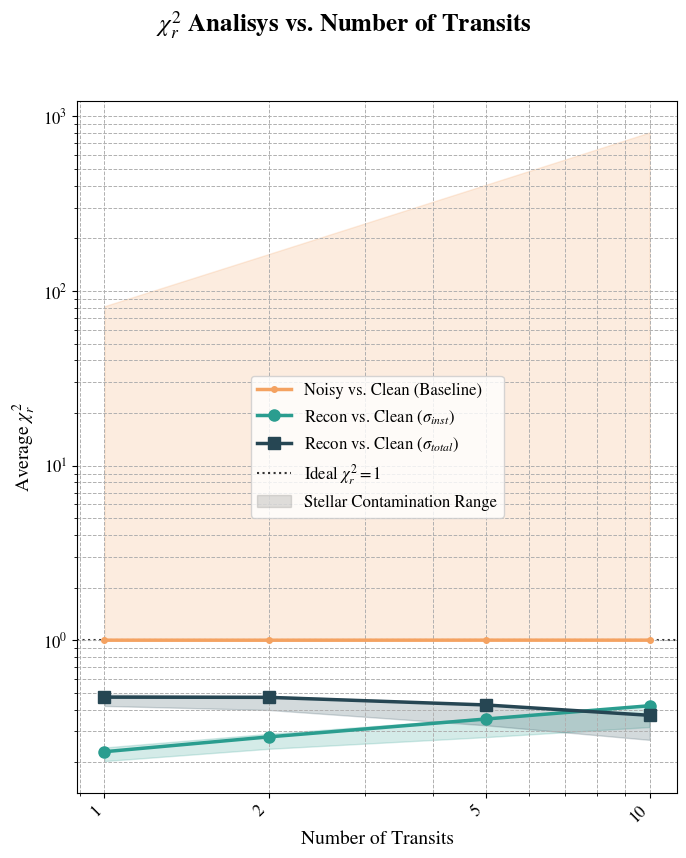

In [31]:
import pickle

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os

# ============================
# Cargar Resultados
# ============================
filename = 'results_sensitivity_uq_final.pkl'
try:
    with open(filename, 'rb') as f:
        all_results = pickle.load(f)
except FileNotFoundError:
    raise RuntimeError(f"Archivo '{filename}' no encontrado. Asegúrate de que el script de cálculo se haya ejecutado y el archivo esté en la misma carpeta.")

# Verificar que el caso base (sin contaminación) existe
base_key = (0.0, 0.0)
case_base = all_results.get(base_key)
if case_base is None:
    raise RuntimeError("No se encontraron datos para el caso base (f_spot=0, f_fac=0).")

# Extraer los valores del eje X
transits_plot = case_base['n_transits']
x_vals = np.array(transits_plot, dtype=float)

# ============================
# Configuración de Plots
# ============================
# <<< CORRECCIÓN: Se cambiaron los nombres de las métricas para que coincidan con el archivo .pkl
# Se reemplazó '_vs_clean_' por '_clean_'.
metrics = [
    'chi2r_noisy_clean_inst',
    'chi2r_recon_clean_inst',
    'chi2r_recon_clean_total'
]

# Etiquetas para la leyenda del gráfico
labels = {
    'chi2r_noisy_clean_inst':  r'Noisy vs. Clean (Baseline)',
    'chi2r_recon_clean_inst':  r'Recon vs. Clean ($\sigma_{inst}$)',
    'chi2r_recon_clean_total': r'Recon vs. Clean ($\sigma_{total}$)',
}

# Paleta de colores y marcadores para cada métrica
palette_colors = ["#F4A261", "#2A9D8F", "#264653", "#E9C46A", "#E76F51"]
palette = {
    'chi2r_noisy_clean_inst':  palette_colors[0],
    'chi2r_recon_clean_inst':  palette_colors[1],
    'chi2r_recon_clean_total': palette_colors[2],
}

markers = {
    'chi2r_noisy_clean_inst':  '.',
    'chi2r_recon_clean_inst':  'o',
    'chi2r_recon_clean_total': 's',
}

def get_min_max(metric, transit_list, results_dict):
    """Calcula el rango min/max en todos los escenarios de contaminación para el sombreado."""
    mins, maxs = [], []
    for nt in transit_list:
        vals = [data[metric][data['n_transits'].index(nt)] 
                for key, data in results_dict.items() 
                if nt in data['n_transits'] and np.isfinite(data[metric][data['n_transits'].index(nt)])]
        if vals:
            mins.append(min(vals))
            maxs.append(max(vals))
        else:
            mins.append(np.nan)
            maxs.append(np.nan)
    return np.array(mins), np.array(maxs)

# ============================
# Crear el Gráfico Unificado
# ============================
fig, ax = plt.subplots(1, 1, figsize=(7,9))

fig.suptitle('$\chi^2_r$ Analisys vs. Number of Transits', fontsize=18, y=0.98, weight='bold')

# Iterar sobre las métricas para plotearlas en el mismo eje
for metric in metrics:
    line_col = palette[metric]

    # 1. Sombreado del rango (todos los casos de f_spot/f_fac)
    mn, mx = get_min_max(metric, transits_plot, all_results)
    ax.fill_between(x_vals, mn, mx, color=line_col, alpha=0.20)

    # 2. Línea principal del caso base (f_spot=0, f_fac=0)
    y_base = [case_base[metric][case_base['n_transits'].index(nt)] if nt in case_base['n_transits'] else np.nan for nt in transits_plot]
    ax.plot(x_vals, y_base, marker=markers[metric], markersize=8, color=line_col, lw=2.5, label=labels[metric])

# 3. Configuración de ejes, grilla y leyenda
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'Average $\chi^2_r$', fontsize=14)
ax.set_xlabel('Number of Transits', fontsize=14)
ax.grid(True, which='both', linestyle='--', linewidth=0.7)
ax.tick_params(axis='both', which='major', labelsize=12)

# Línea de referencia en y=1
ax.axhline(1, color='black', linestyle=':', lw=1.5, alpha=0.8, zorder=0, label=r'Ideal $\chi^2_r = 1$')

# Forzar que todas las etiquetas aparezcan en la leyenda
handles, labels_ax = ax.get_legend_handles_labels()
# Añadir etiqueta para el área sombreada
handles.append(plt.Rectangle((0,0),1,1, color='gray', alpha=0.25))
labels_ax.append('Stellar Contamination Range')
ax.legend(handles=handles, labels=labels_ax, fontsize=12, loc='best')

# Formato del eje X para que muestre números en lugar de notación científica
ax.set_xticks(transits_plot)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Guardar figura
output_dir = 'plots'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(output_dir, 'chi2r_analysis_all.png'), dpi=300)
plt.savefig(os.path.join(output_dir, 'chi2r_analysis_all.svg'))
plt.show()

<>:78: SyntaxWarning: invalid escape sequence '\c'
<>:78: SyntaxWarning: invalid escape sequence '\c'
C:\Users\User\AppData\Local\Temp\ipykernel_76392\2881048535.py:78: SyntaxWarning: invalid escape sequence '\c'
  fig.suptitle('$\chi^2_r$ Analysis: Impact of Stellar Activity', fontsize=18, y=0.96, weight='bold')


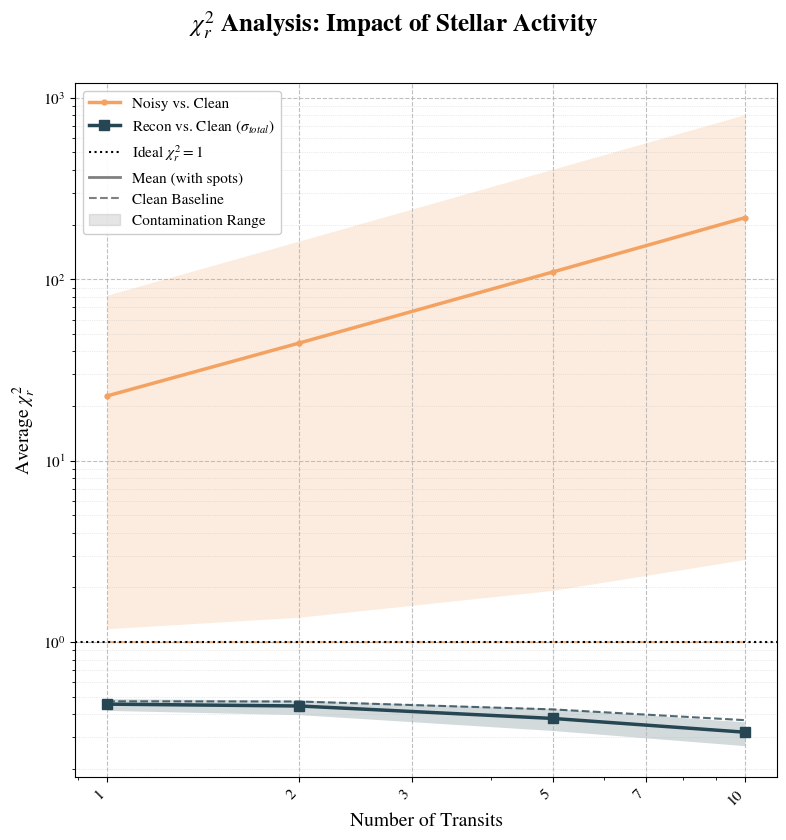

In [35]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
from matplotlib.lines import Line2D

# ============================
# 1. Configuración y Carga
# ============================
filename = 'results_sensitivity_uq_final.pkl'
try:
    with open(filename, 'rb') as f:
        all_results = pickle.load(f)
except FileNotFoundError:
    # Generamos datos dummy si no existe el archivo para que el código sea testeable
    print(f"Advertencia: '{filename}' no encontrado. Usando datos simulados para demostración.")
    all_results = {}
    transits_dummy = [1, 2, 3, 5, 7, 10, 15, 20]
    
    # Caso Base (Clean)
    all_results[(0.0, 0.0)] = {
        'n_transits': transits_dummy,
        'chi2r_noisy_clean_inst': [1.0] * 8,
        'chi2r_recon_clean_total': [0.5 * (t**-0.1) for t in transits_dummy]
    }
    # Casos Contaminados (Simulados)
    for i in range(10):
        noise = np.random.normal(0, 0.05, 8)
        offset = np.random.uniform(0.1, 0.5)
        all_results[(0.01*(i+1), 0.01*(i+1))] = {
            'n_transits': transits_dummy,
            'chi2r_noisy_clean_inst': [1.0 + offset + n + (t/100) for n, t in zip(noise, transits_dummy)],
            'chi2r_recon_clean_total': [0.5 * (t**-0.1) + offset/2 + n for n, t in zip(noise, transits_dummy)]
        }

# Definir la llave del caso base
base_key = (0.0, 0.0)
case_base = all_results.get(base_key)

if case_base is None:
    raise RuntimeError("No se encontraron datos para el caso base (f_spot=0, f_fac=0).")

# Extraer eje X
transits_plot = case_base['n_transits']
x_vals = np.array(transits_plot, dtype=float)

# ============================
# 2. Estilos y Métricas
# ============================
metrics = [
    'chi2r_noisy_clean_inst',
    'chi2r_recon_clean_total'
]

labels_metric = {
    'chi2r_noisy_clean_inst':  r'Noisy vs. Clean',
    'chi2r_recon_clean_total': r'Recon vs. Clean ($\sigma_{total}$)',
}

# Colores definidos
palette = {
    'chi2r_noisy_clean_inst':  "#F4A261", # Naranja
    'chi2r_recon_clean_total': "#264653", # Azul oscuro
}

markers = {
    'chi2r_noisy_clean_inst':  '.',
    'chi2r_recon_clean_total': 's',
}

# ============================
# 3. Plot Principal
# ============================
fig, ax = plt.subplots(1, 1, figsize=(8, 9)) # Un poco más ancho para que respire

fig.suptitle('$\chi^2_r$ Analysis: Impact of Stellar Activity', fontsize=18, y=0.96, weight='bold')

for metric in metrics:
    color = palette[metric]
    marker = markers[metric]
    
    # --- A. Calcular Estadísticas (Min, Max, Mean) de casos Contaminados ---
    mins, maxs, means = [], [], []
    
    for nt in transits_plot:
        vals = []
        # Recorremos todos los escenarios EXCEPTO el base
        for key, data in all_results.items():
            if key == base_key: continue 
            
            if nt in data['n_transits']:
                idx = data['n_transits'].index(nt)
                val = data[metric][idx]
                if np.isfinite(val):
                    vals.append(val)
        
        if vals:
            mins.append(min(vals))
            maxs.append(max(vals))
            means.append(np.mean(vals))
        else:
            mins.append(np.nan); maxs.append(np.nan); means.append(np.nan)

    # --- B. Plotear Sombra (Rango de contaminación) ---
    ax.fill_between(transits_plot, mins, maxs, 
                    color=color, alpha=0.2, lw=0)

    # --- C. Plotear Promedio Contaminado (Línea Sólida) ---
    ax.plot(transits_plot, means, 
            marker=marker, markersize=7,
            color=color, lw=2.5, linestyle='-',
            label=labels_metric[metric]) # Etiqueta principal para el color

    # --- D. Plotear Baseline "Clean" (Línea Punteada) ---
    # Extraemos datos del caso base
    y_base = []
    for nt in transits_plot:
        if nt in case_base['n_transits']:
            y_base.append(case_base[metric][case_base['n_transits'].index(nt)])
        else:
            y_base.append(np.nan)
            
    # La dibujamos del mismo color pero punteada y ligeramente transparente
    ax.plot(transits_plot, y_base, 
            color=color, lw=1.5, linestyle='--', alpha=0.8)

# ============================
# 4. Configuración de Ejes (Ticks aumentados)
# ============================
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'Average $\chi^2_r$', fontsize=14)
ax.set_xlabel('Number of Transits', fontsize=14)

# --- EJE X: Ticks manuales para rellenar huecos visuales ---
# Tus datos + intermedios (4, 6, 8, 9, 12, 18)
custom_ticks = sorted(list(set(transits_plot) | {3,7}))
ax.set_xticks(custom_ticks)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter()) # Números normales (no 10^1)
ax.ticklabel_format(axis='x', style='plain') # Evita notación científica forzada
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# --- EJE Y: Subdivisiones logarítmicas tupidas ---
# Pone rayitas en 0.2, 0.3... 2, 3, 4... etc
locmin = ticker.LogLocator(base=10.0, subs=(0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), numticks=12)
ax.yaxis.set_minor_locator(locmin)
ax.yaxis.set_minor_formatter(ticker.NullFormatter()) # Solo rayitas, sin números

# Grilla
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.8)
ax.grid(True, which='minor', axis='y', linestyle=':', linewidth=0.5, alpha=0.5)

# Línea de referencia ideal
ax.axhline(1, color='black', linestyle=':', lw=1.5, label=r'Ideal $\chi^2_r = 1$')

# ============================
# 5. Leyenda Personalizada
# ============================
handles, labels_ax = ax.get_legend_handles_labels()

# Crear sección explicativa de estilos
# Línea Sólida
handles.append(Line2D([0], [0], color='gray', linestyle='-', lw=2))
labels_ax.append('Mean (with spots)')

# Línea Punteada
handles.append(Line2D([0], [0], color='gray', linestyle='--', lw=1.5))
labels_ax.append('Clean Baseline')

# Sombra
handles.append(plt.Rectangle((0,0),1,1, color='gray', alpha=0.2))
labels_ax.append('Contamination Range')

# Ordenar leyenda: Primero métricas, luego referencia, luego explicación de estilos
ax.legend(handles=handles, labels=labels_ax, fontsize=11, loc='upper left', framealpha=0.95)

# ============================
# 6. Guardar
# ============================
output_dir = 'plots'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(output_dir, 'chi2r_analysis_final_02.png'), dpi=300)
plt.show()

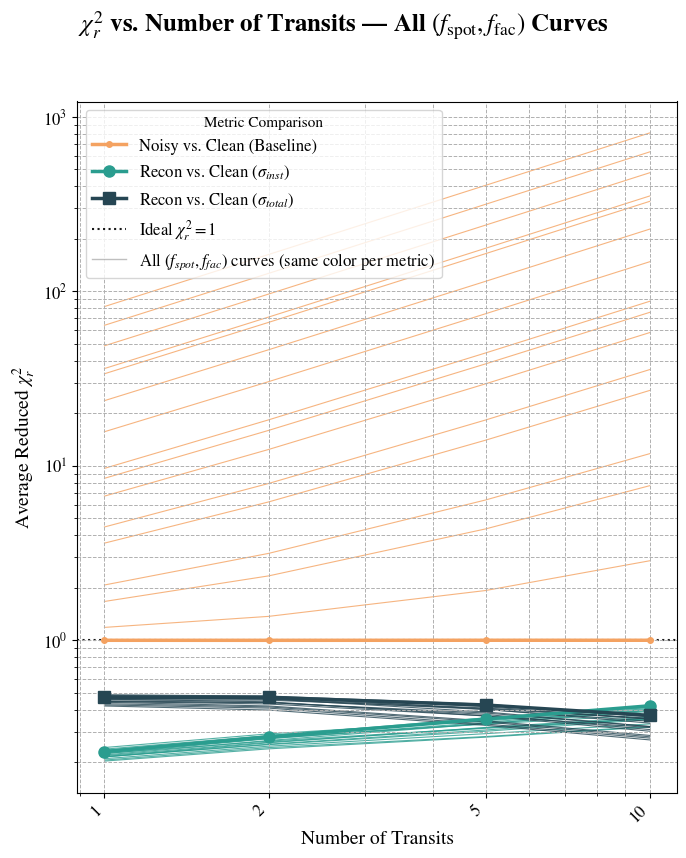

In [36]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# ============================
# Load results
# ============================
filename = 'results_sensitivity_uq_final.pkl'
try:
    with open(filename, 'rb') as f:
        all_results = pickle.load(f)
except FileNotFoundError:
    raise RuntimeError(
        f"File '{filename}' not found. Make sure the compute script ran "
        "and the file is in the same folder."
    )

# Check the base (no contamination) exists
base_key = (0.0, 0.0)
case_base = all_results.get(base_key)
if case_base is None:
    raise RuntimeError("Missing base case (f_spot=0, f_fac=0) in results.")

# X axis (number of transits)
transits_plot = case_base['n_transits']
x_vals = np.array(transits_plot, dtype=float)

# ============================
# Plot configuration
# ============================
metrics = [
    'chi2r_noisy_clean_inst',
    'chi2r_recon_clean_inst',
    'chi2r_recon_clean_total',
]

labels = {
    'chi2r_noisy_clean_inst':  r'Noisy vs. Clean (Baseline)',
    'chi2r_recon_clean_inst':  r'Recon vs. Clean ($\sigma_{inst}$)',
    'chi2r_recon_clean_total': r'Recon vs. Clean ($\sigma_{total}$)',
}

# One color per metric; all contamination curves use the same color as their metric
palette_colors = ["#F4A261", "#2A9D8F", "#264653"]
palette = {
    'chi2r_noisy_clean_inst':  palette_colors[0],
    'chi2r_recon_clean_inst':  palette_colors[1],
    'chi2r_recon_clean_total': palette_colors[2],
}

markers = {
    'chi2r_noisy_clean_inst':  '.',
    'chi2r_recon_clean_inst':  'o',
    'chi2r_recon_clean_total': 's',
}

def series_for_metric_at_transits(data_dict, metric, transits_ref):
    """
    Return y-values for 'metric' aligned to transits_ref using the
    indexes from 'data_dict["n_transits"]'. Non-existing points -> np.nan.
    """
    ys = []
    t_list = data_dict.get('n_transits', [])
    for nt in transits_ref:
        if nt in t_list:
            idx = t_list.index(nt)
            val = data_dict[metric][idx]
        else:
            val = np.nan
        ys.append(val)
    return np.array(ys, dtype=float)

# ============================
# Make the unified plot
# ============================
fig, ax = plt.subplots(1, 1, figsize=(7, 9))
fig.suptitle(r'$\chi^2_r$ vs. Number of Transits — All $(f_{\mathrm{spot}}, f_{\mathrm{fac}})$ Curves',
             fontsize=18, y=0.98, weight='bold')

# Draw all contamination curves (thin, semi-transparent) + highlight base case
for metric in metrics:
    color = palette[metric]

    # 1) All (f_spot, f_fac) scenarios (same color, thin lines)
    #    Skip the base key for this layer; we'll plot it thicker later.
    for key, data in all_results.items():
        if key == base_key:
            continue
        if metric not in data:
            continue
        y_vals = series_for_metric_at_transits(data, metric, transits_plot)

        # Plot only if we have at least two finite points
        finite = np.isfinite(y_vals)
        if np.count_nonzero(finite) >= 2:
            ax.plot(
                x_vals[finite],
                y_vals[finite],
                lw=0.8,
                alpha=0.8,
                color=color,
                zorder=1,
            )

    # 2) Base case (thicker, markers, on top)
    y_base = series_for_metric_at_transits(case_base, metric, transits_plot)
    finite_base = np.isfinite(y_base)
    if np.count_nonzero(finite_base) >= 2:
        ax.plot(
            x_vals[finite_base],
            y_base[finite_base],
            marker=markers[metric],
            markersize=8,
            color=color,
            lw=2.5,
            label=labels[metric],
            zorder=3,
        )

# Axes, grid, legend
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'Average Reduced $\chi^2_r$', fontsize=14)
ax.set_xlabel('Number of Transits', fontsize=14)
ax.grid(True, which='both', linestyle='--', linewidth=0.7)
ax.tick_params(axis='both', which='major', labelsize=12)

# Reference line at y = 1
ax.axhline(1, color='black', linestyle=':', lw=1.5, alpha=0.9, zorder=0,
           label=r'Ideal $\chi^2_r = 1$')

# Legend: add a proxy thin line for "All contamination curves"
from matplotlib.lines import Line2D
proxy = Line2D([0], [0], lw=1.0, alpha=0.5, color='gray')
handles, labels_ax = ax.get_legend_handles_labels()
handles.append(proxy)
labels_ax.append('All $(f_{spot}, f_{fac})$ curves (same color per metric)')
ax.legend(handles=handles, labels=labels_ax, fontsize=12, loc='best',
          title="Metric Comparison")

# X tick formatting (show the actual numbers instead of scientific notation)
ax.set_xticks(x_vals)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Save figure
output_dir = 'plots'
os.makedirs(output_dir, exist_ok=True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()
